# llm-assist showcase (end-to-end)

This notebook demonstrates the full project idea from the repository:

- **EDA** on the bundled golden dataset (and optionally a labeled CSV)
- **Offline evaluation** (golden set)
- **Deep learning alternate path**: optional **BERT/RoBERTa** fine-tuning for category
- **Run the FastAPI service** via **uvicorn subprocess** and call the endpoints

Primary references:
- `README.md`
- `docs/IMPLEMENTATION_REPORT.md` (especially section **6**)
- `docs/METHODOLOGY_EDA_AND_DL.md`


## 0) Setup

This notebook uses subprocess calls to run scripts and start the API.

Install dependencies in your venv:

```bash
pip install -e ".[dev,eda,transformer]"
```

Notes:
- Outputs go under `artifacts/` (gitignored).
- The transformer training section can take time depending on hardware.


In [33]:
import sys, os
print(sys.executable)
print(os.getcwd())

/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/bin/python
/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist


In [34]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

import requests

# Works whether notebook starts in repo root or notebooks/
cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "app").is_dir() else cwd.parent
assert (ROOT / "app").is_dir(), f"Could not find repo root from {cwd}"
os.chdir(ROOT)  # make all relative paths consistent
print("Repo root:", ROOT)
print("Python:", sys.version)
print("Executable:", sys.executable)


Repo root: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist
Python: 3.11.6 (main, Feb  7 2025, 13:40:10) [Clang 16.0.0 (clang-1600.0.26.4)]
Executable: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/bin/python


## 1) Project idea (what we built)

From `README.md`: a production-grade FastAPI service that uses an **LLM** to triage tickets, evaluate agent-response quality, and summarize threads, with optional RAG and offline eval.

For the **deep learning narrative** (implemented vs literature/future work), see `docs/IMPLEMENTATION_REPORT.md` section **6**.


In [35]:
print((ROOT / "README.md").read_text(encoding="utf-8").splitlines()[0])
print()
print("Docs:")
print("-", ROOT / "docs" / "IMPLEMENTATION_REPORT.md")
print("-", ROOT / "docs" / "METHODOLOGY_EDA_AND_DL.md")


# LLM-Augmented Customer Support Triage & Quality Monitoring

Docs:
- /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/docs/IMPLEMENTATION_REPORT.md
- /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/docs/METHODOLOGY_EDA_AND_DL.md


## 2) EDA (exploratory plots)

We generate plots from the bundled golden set (`data/golden/eval_set.jsonl`).

Outputs are written to `artifacts/eda/`.

In [36]:
eda_out = ROOT / "artifacts" / "eda"

# Run EDA script (requires: pip install -e ".[eda]")
subprocess.check_call(
    [sys.executable, "scripts/run_eda.py"],
    cwd=str(ROOT),
    env={**os.environ, "PYTHONUNBUFFERED": "1"},
)

print("EDA output dir:", eda_out)
print("Files:")
for p in sorted(eda_out.glob("*.png")):
    print("-", p.name)


Wrote golden-set figures under /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/eda
EDA output dir: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/eda
Files:
- golden_task_counts.png
- golden_text_length_by_task.png
- golden_triage_category.png
- golden_triage_priority.png


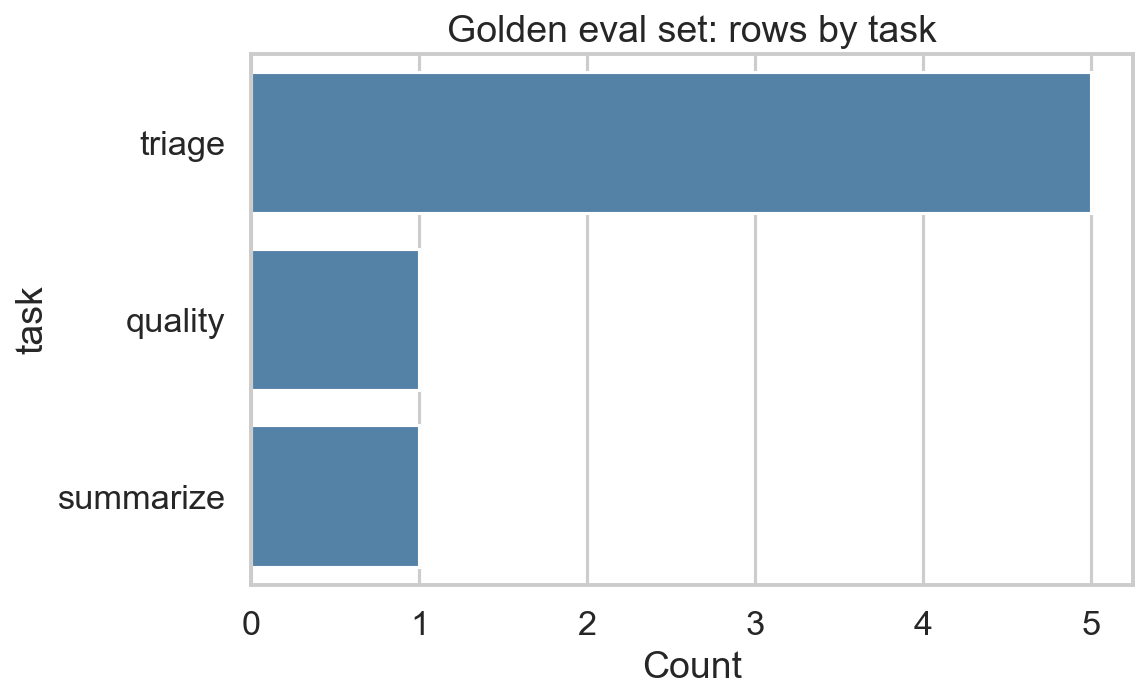

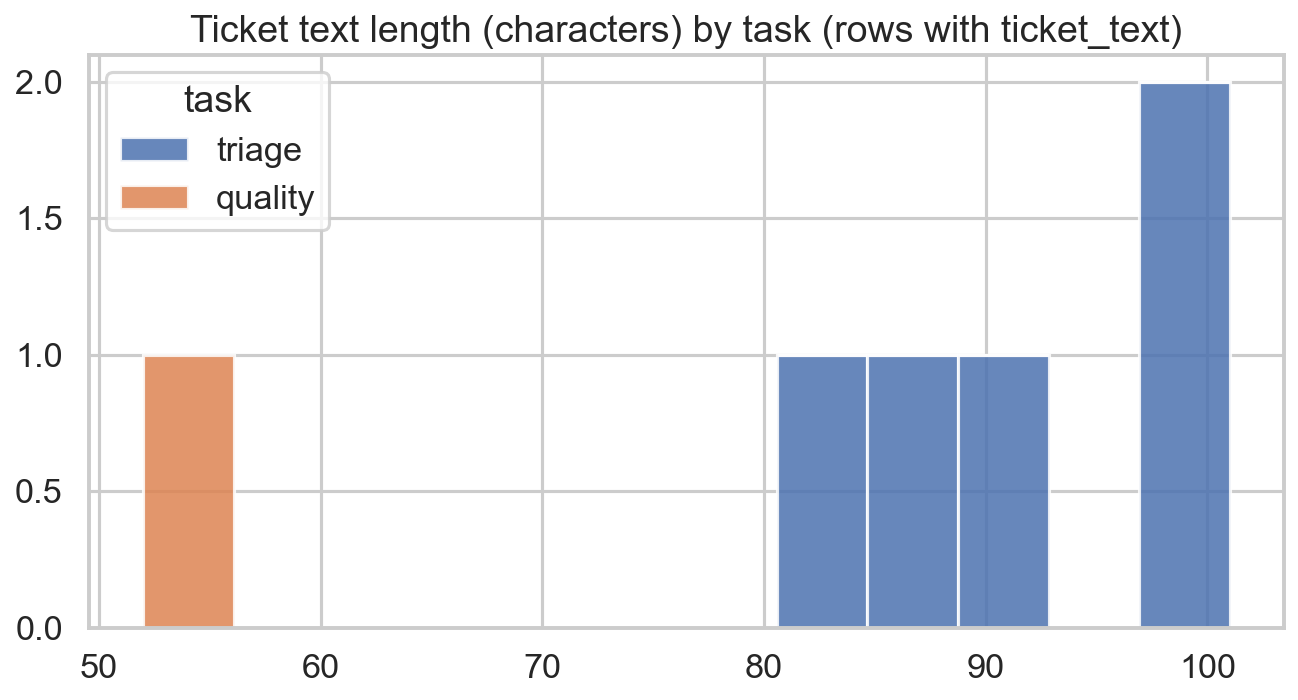

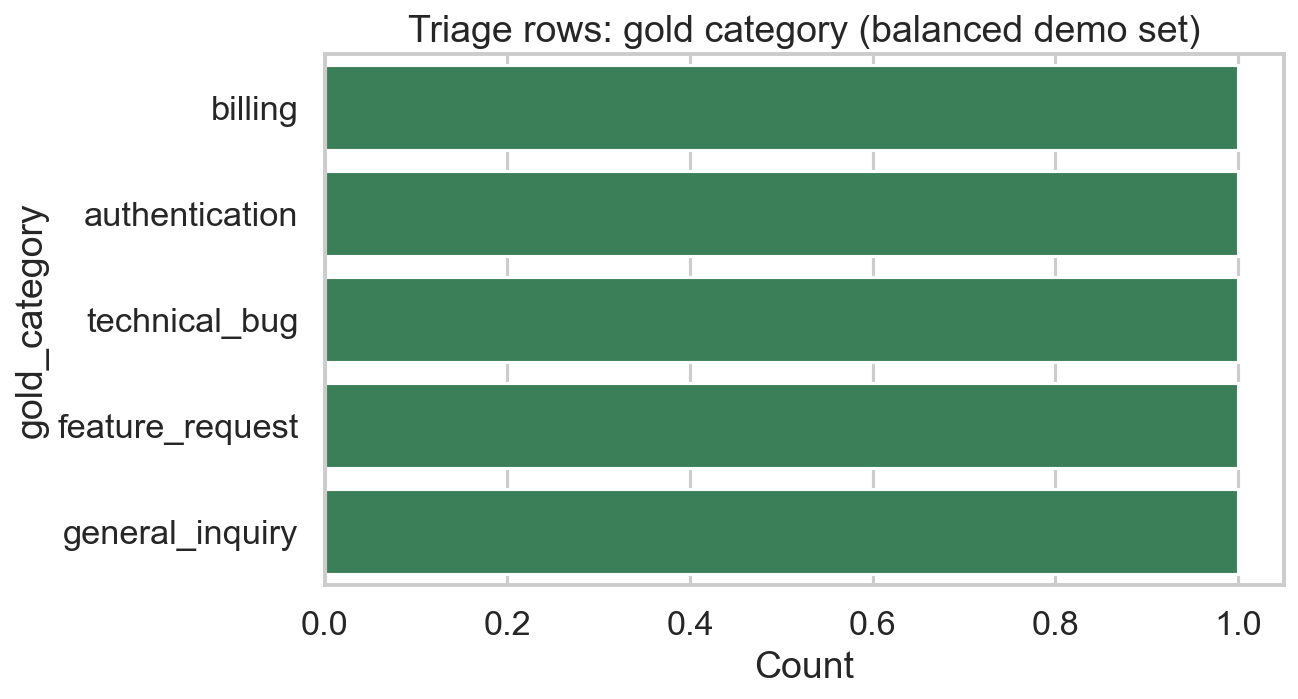

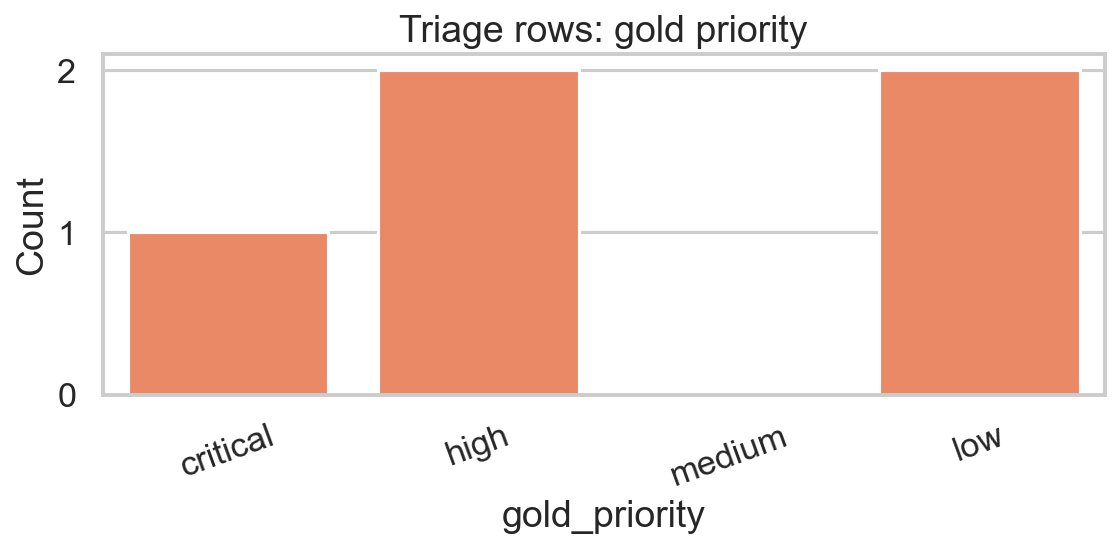

In [37]:
# Display figures inline
from IPython.display import Image, display

for p in sorted((ROOT / "artifacts" / "eda").glob("*.png")):
    display(Image(filename=str(p)))


## 3) Offline evaluation (golden set)

Runs the reproducible benchmark on `data/golden/eval_set.jsonl` and prints the markdown summary from `artifacts/eval/summary.md`.

In [38]:
subprocess.check_call(
    [
        sys.executable,
        "scripts/run_offline_eval.py",
        "--data",
        "data/golden/eval_set.jsonl",
    ],
    cwd=str(ROOT),
    env={
        **os.environ,
        # settings validation in CI expects a long enough secret
        "APP_SECRET_KEY": os.environ.get("APP_SECRET_KEY", "test-secret-key-minimum-16chars"),
        "QUALITY_POLICY_CONTEXT_TOP_K": os.environ.get("QUALITY_POLICY_CONTEXT_TOP_K", "0"),
        "TRIAGE_POLICY_CONTEXT_TOP_K": os.environ.get("TRIAGE_POLICY_CONTEXT_TOP_K", "0"),
        "PYTHONUNBUFFERED": "1",
    },
)

summary_path = ROOT / "artifacts" / "eval" / "summary.md"
print(summary_path.read_text(encoding="utf-8"))


2026-04-27 12:30:45 [warning  ] Embedding fallback disabled: sentence-transformers unavailable error="No module named 'sentence_transformers'"
2026-04-27 12:30:45 [info     ] Starting triage                ticket_length=101


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5837.77it/s]


2026-04-27 12:30:51 [info     ] Triage complete                category=billing priority=critical sentiment=-0.2 team=critical_response
2026-04-27 12:30:51 [info     ] Starting triage                ticket_length=101
2026-04-27 12:30:51 [info     ] Triage complete                category=authentication priority=high sentiment=-0.2 team=auth_security
2026-04-27 12:30:51 [info     ] Starting triage                ticket_length=87
2026-04-27 12:30:51 [info     ] Triage complete                category=technical_bug priority=high sentiment=-0.2 team=tier2_engineering
2026-04-27 12:30:51 [info     ] Starting triage                ticket_length=90
2026-04-27 12:30:51 [info     ] Triage complete                category=feature_request priority=low sentiment=-0.2 team=product_team
2026-04-27 12:30:51 [info     ] Starting triage                ticket_length=82
2026-04-27 12:30:51 [info     ] Triage complete                category=general_inquiry priority=low sentiment=-0.2 team=general_support

## 4) Deep learning demo (alternate method): fine-tune RoBERTa/BERT for category

This section runs a **real Hugging Face `Trainer`** fine-tune for the single task:

- input: CSV with columns `text,category`
- output: a checkpoint directory under `artifacts/` with `config.json`, tokenizer files, and weights

If you do not have a real labeled CSV downloaded yet, we generate a small demo CSV in `artifacts/demo_tickets.csv` so the training loop is still reproducible.

Install requirement:

```bash
pip install -e ".[transformer]"
```


In [39]:
demo_csv = ROOT / "artifacts" / "demo_tickets.csv"

def write_demo_csv(path: Path) -> None:
    # 5 categories matching app.models.domain.Category
    rows = [
        ("charged twice for subscription", "billing"),
        ("refund not received for invoice", "billing"),
        ("cannot log in password reset fails", "authentication"),
        ("2FA code not working login blocked", "authentication"),
        ("export button crashes chrome", "technical_bug"),
        ("app freezes on settings screen", "technical_bug"),
        ("please add dark mode", "feature_request"),
        ("can you add SSO support", "feature_request"),
        ("what are your support hours", "general_inquiry"),
        ("where can I find API docs", "general_inquiry"),
    ]

    path.parent.mkdir(parents=True, exist_ok=True)
    lines = ["text,category\n"] + [f"{t},{c}\n" for t, c in rows]
    path.write_text("".join(lines), encoding="utf-8")

if not demo_csv.is_file():
    write_demo_csv(demo_csv)

print("Training CSV:", demo_csv)
print(demo_csv.read_text(encoding="utf-8"))


Training CSV: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/demo_tickets.csv
text,category
charged twice for subscription,billing
refund not received for invoice,billing
cannot log in password reset fails,authentication
2FA code not working login blocked,authentication
export button crashes chrome,technical_bug
app freezes on settings screen,technical_bug
please add dark mode,feature_request
can you add SSO support,feature_request
what are your support hours,general_inquiry
where can I find API docs,general_inquiry



In [40]:
model_dir = ROOT / "artifacts" / "triage_roberta_demo"

# Keep this short for a classroom demo
cmd = [
    sys.executable,
    "scripts/train_triage_transformer.py",
    "--data",
    str(demo_csv),
    "--out",
    str(model_dir),
    "--model",
    "roberta-base",
    "--epochs",
    "1",
    "--batch-size",
    "4",
]

print("Running:", " ".join(cmd))
subprocess.check_call(cmd, cwd=str(ROOT), env={**os.environ, "PYTHONUNBUFFERED": "1"})

metrics_path = model_dir / "train_metrics.json"
print("Checkpoint dir:", model_dir)
print("Metrics path:", metrics_path)
print(metrics_path.read_text(encoding="utf-8"))


Running: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/bin/python scripts/train_triage_transformer.py --data /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/demo_tickets.csv --out /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/triage_roberta_demo --model roberta-base --epochs 1 --batch-size 4


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8345.31it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
  0%|          | 0/2 [00:00<?, ?it/s]/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/lib/python

{'eval_loss': '1.634', 'eval_accuracy': '0', 'eval_runtime': '0.3166', 'eval_samples_per_second': '6.316', 'eval_steps_per_second': '3.158', 'epoch': '1'}



100%|██████████| 2/2 [00:04<00:00,  1.68it/s]

{'train_runtime': '4.215', 'train_samples_per_second': '1.898', 'train_steps_per_second': '0.474', 'train_loss': '1.657', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.42it/s]
/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1/1 [00:00<00:00, 226.05it/s]


Saved checkpoint to /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/triage_roberta_demo
Metrics: {'eval_loss': 1.6342341899871826, 'eval_accuracy': 0.0, 'eval_runtime': 0.2742, 'eval_samples_per_second': 7.295, 'eval_steps_per_second': 3.647, 'epoch': 1.0}
Checkpoint dir: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/triage_roberta_demo
Metrics path: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/artifacts/triage_roberta_demo/train_metrics.json
{
  "eval_loss": 1.6342341899871826,
  "eval_accuracy": 0.0,
  "eval_runtime": 0.2742,
  "eval_samples_per_second": 7.295,
  "eval_steps_per_second": 3.647,
  "epoch": 1.0
}


To use this optional encoder inside the service, set:

- `TRIAGE_TRANSFORMER_ENABLED=true`
- `TRIAGE_TRANSFORMER_MODEL_DIR=artifacts/triage_roberta_demo`

This model is used only as a **category hint** prepended to the LLM prompt; the LLM remains responsible for returning the full structured triage JSON.


## 5) Run the API (uvicorn subprocess) and call endpoints

We start uvicorn in the background, poll `/api/v1/health`, then call:

- `/api/v1/triage`
- `/api/v1/quality`
- `/api/v1/pipeline`
- `/api/v1/summarize`
- `/api/v1/rag/context`

Reliability notes for hosted/local models:

- Keep request timeout high (120-210s) for first-call warm-up.
- Run one warm-up `/api/v1/triage` call before the full block if latency is high.
- If uvicorn is already running in a terminal, skip the notebook uvicorn startup/shutdown cells and run only endpoint call cells.
- For hosted-model taxonomy drift (e.g., `refund`), enable fallback in `.env` with `TRIAGE_EMBEDDING_FALLBACK_ENABLED=true`.

Finally, we shut the server down.


In [41]:
API_BASE = "http://127.0.0.1:8000"

# Start uvicorn as a subprocess
env = {
    **os.environ,
    "APP_SECRET_KEY": os.environ.get("APP_SECRET_KEY", "test-secret-key-minimum-16chars"),
    "QUALITY_POLICY_CONTEXT_TOP_K": os.environ.get("QUALITY_POLICY_CONTEXT_TOP_K", "0"),
    "TRIAGE_POLICY_CONTEXT_TOP_K": os.environ.get("TRIAGE_POLICY_CONTEXT_TOP_K", "0"),
    # Enable the optional encoder hint we just trained (safe even if deps missing; service will skip)
    "TRIAGE_TRANSFORMER_ENABLED": "true",
    "TRIAGE_TRANSFORMER_MODEL_DIR": str(model_dir),
    "PYTHONUNBUFFERED": "1",
}

uvicorn_cmd = [sys.executable, "-m", "uvicorn", "app.main:app", "--host", "127.0.0.1", "--port", "8000"]
print("Starting:", " ".join(uvicorn_cmd))
proc = subprocess.Popen(
    uvicorn_cmd,
    cwd=str(ROOT),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

# Wait for /health
deadline = time.time() + 30
last_err = None
while time.time() < deadline:
    try:
        r = requests.get(f"{API_BASE}/api/v1/health", timeout=1.5)
        if r.status_code == 200:
            print("API ready:", r.json())
            break
    except Exception as e:
        last_err = e
    time.sleep(0.5)
else:
    raise RuntimeError(f"API did not become ready. Last error: {last_err}")


Starting: /Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/llm-assist/.venv/bin/python -m uvicorn app.main:app --host 127.0.0.1 --port 8000
API ready: {'status': 'healthy', 'version': '1.0.0', 'checks': {'redis': 'ok', 'config': 'ok'}}


In [42]:
import os
os.environ["LLM_PROFILE"] = "ollama"
os.environ["LLM_PROVIDER"] = "ollama"   # defensive
os.environ.pop("ANTHROPIC_API_KEY", None)
os.environ["LLM_TIMEOUT_SECONDS"] = "120"   # avoid 30s timeout on local model

In [43]:
def post_json(path: str, payload: dict, *, timeout: int = 210, retries: int = 2) -> dict:
    last_response = None
    for attempt in range(retries + 1):
        r = requests.post(f"{API_BASE}{path}", json=payload, timeout=timeout)
        last_response = r
        if r.ok:
            return r.json()
        if attempt < retries:
            time.sleep(1.5)

    assert last_response is not None
    print(f"{path} failed ({last_response.status_code}):")
    try:
        print(json.dumps(last_response.json(), indent=2))
    except Exception:
        print(last_response.text)
    last_response.raise_for_status()
    return {}

sample_ticket = "I was charged twice this month and need a refund immediately."

# Warm-up call (reduces first-call latency variance on local/hosted models)
_ = post_json("/api/v1/triage", {"ticket_text": sample_ticket, "include_policy_context": False})

triage = post_json("/api/v1/triage", {"ticket_text": sample_ticket, "include_policy_context": False})
print("/triage:\n", json.dumps(triage, indent=2))

quality = post_json(
    "/api/v1/quality",
    {
        "ticket_text": sample_ticket,
        "agent_response": "Sorry about that. I opened a billing case and will refund within 24 hours.",
        "include_policy_context": False,
    },
)
print("\n/quality:\n", json.dumps(quality, indent=2))

pipeline = post_json(
    "/api/v1/pipeline",
    {
        "ticket_text": sample_ticket,
        "agent_response": "Sorry about that. I opened a billing case and will refund within 24 hours.",
    },
)
print("\n/pipeline:\n", json.dumps(pipeline, indent=2))

summ = post_json(
    "/api/v1/summarize",
    {
        "turns": [
            {"role": "customer", "content": "The app freezes when I open settings."},
            {
                "role": "agent",
                "content": "Please clear cache and update to 2.4. I will follow up tomorrow.",
            },
        ]
    },
)
print("\n/summarize:\n", json.dumps(summ, indent=2))

rag = post_json("/api/v1/rag/context", {"query": "refund timeline", "top_k": 2})
print("\n/rag/context:\n", json.dumps(rag, indent=2))


/triage:
 {
  "priority": "critical",
  "category": "authentication",
  "intents": [
    {
      "label": "authentication",
      "score": 0.9
    },
    {
      "label": "billing",
      "score": 0.8
    }
  ],
  "sentiment_score": -1.0,
  "routed_team": "escalations",
  "rationale": "The customer is experiencing a critical issue with duplicate charges, which requires immediate attention for authentication and billing purposes.",
  "confidence": 0.95
}

/quality:
 {
  "score": 0.75,
  "passed": true,
  "checks": {
    "empathetic_tone": true,
    "actionable_next_step": true,
    "policy_safety": true,
    "resolved_or_escalated": true
  },
  "coaching_feedback": "The response acknowledges the customer's frustration with 'Sorry about that', but could be more empathetic. The next step is clear and specific, but consider adding a confirmation of the refund process.",
  "flagged_phrases": []
}

/pipeline:
 {
  "triage": {
    "priority": "critical",
    "category": "authentication",
    

In [44]:
# Shutdown uvicorn
try:
    proc.terminate()
    proc.wait(timeout=10)
except Exception:
    proc.kill()

# Print last ~200 lines of server output for debugging
if proc.stdout is not None:
    out = proc.stdout.read()
    lines = out.splitlines()[-200:]
    print("\n".join(lines))

print("Server stopped.")


INFO:     Started server process [1803]
INFO:     Waiting for application startup.
2026-04-27T16:31:04.874177Z [info     ] Application starting           [app.main] env=development llm_provider=ollama model=qwen3.5:4b service=support-triage
INFO:     Application startup complete.
ERROR:    [Errno 48] error while attempting to bind on address ('127.0.0.1', 8000): address already in use
INFO:     Waiting for application shutdown.
2026-04-27T16:31:04.876076Z [info     ] Application shutting down      [app.main] service=support-triage
INFO:     Application shutdown complete.
Server stopped.
